In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel(r"C:\Dev\Projects\ola-ride-insights\data\OLA_DataSet.xlsx")

df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


In [6]:
df.shape

(103024, 20)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[us]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  str           
 3   Booking_Status              103024 non-null  str           
 4   Customer_ID                 103024 non-null  str           
 5   Vehicle_Type                103024 non-null  str           
 6   Pickup_Location             103024 non-null  str           
 7   Drop_Location               103024 non-null  str           
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   str           
 11  Canceled_Rides_by_Driver    18434 non-null   str  

In [8]:
df.describe()

,Date,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,103024,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000
mean,2024-07-16 11:31:38.879678,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313
min,2024-07-01 00:00:00,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000
25%,2024-07-08 18:41:00,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000
50%,2024-07-16 11:23:00,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000
75%,2024-07-24 05:18:00,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000
max,2024-07-31 23:58:00,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000
std,NaN,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957


In [9]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images'],
      dtype='str')

In [10]:
df.isnull().sum()

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Booking_Value                     0
Payment_Method                39057
Ride_Distance                     0
Driver_Ratings                39057
Customer_Rating               39057
Vehicle Images                    0
dtype: int64

In [11]:
df['Payment_Method'].fillna('Unknown', inplace=True)

C:\Users\divya\AppData\Local\Temp\ipykernel_22028\993409845.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Payment_Method'].fillna('Unknown', inplace=True)


0             Unknown
1                Cash
2                 UPI
3             Unknown
4         Credit Card
             ...     
103019           Cash
103020            UPI
103021           Cash
103022            UPI
103023            UPI
Name: Payment_Method, Length: 103024, dtype: str

In [12]:
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

In [13]:
df['Driver_Ratings'] = df['Driver_Ratings'].fillna(0)

In [14]:
df['Customer_Rating'] = df['Customer_Rating'].fillna(0)

In [15]:
df['Incomplete_Rides'] = df['Incomplete_Rides'].fillna('No')

In [16]:
df['Canceled_Rides_by_Customer'] = df['Canceled_Rides_by_Customer'].fillna('Not Cancelled')

In [17]:
df['Canceled_Rides_by_Driver'] = df['Canceled_Rides_by_Driver'].fillna('Not Cancelled')

In [18]:
df['Incomplete_Rides_Reason'] = df['Incomplete_Rides_Reason'].fillna('Not Applicable')

In [19]:
df = df.drop(columns=['Vehicle Images'])

In [20]:
df.isnull().sum()

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer        0
Canceled_Rides_by_Driver          0
Incomplete_Rides                  0
Incomplete_Rides_Reason           0
Booking_Value                     0
Payment_Method                    0
Ride_Distance                     0
Driver_Ratings                    0
Customer_Rating                   0
dtype: int64

In [21]:
df = df.drop(columns=['V_TAT', 'C_TAT'])

In [22]:
df.isnull().sum()

Date                          0
Time                          0
Booking_ID                    0
Booking_Status                0
Customer_ID                   0
Vehicle_Type                  0
Pickup_Location               0
Drop_Location                 0
Canceled_Rides_by_Customer    0
Canceled_Rides_by_Driver      0
Incomplete_Rides              0
Incomplete_Rides_Reason       0
Booking_Value                 0
Payment_Method                0
Ride_Distance                 0
Driver_Ratings                0
Customer_Rating               0
dtype: int64

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df['Hour'] = df['Time'].apply(lambda x: x.hour)

In [26]:
df['Day'] = df['Date'].dt.day_name()

In [27]:
df['Month'] = df['Date'].dt.month

In [28]:
df['Peak_Hour'] = df['Hour'].apply(
    lambda x: 'Peak' if 7 <= x <= 10 or 17 <= x <= 21 else 'Non-Peak'
)

In [29]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,...,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Hour,Day,Month,Peak_Hour
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,Not Cancelled,Personal & Car related issue,...,Not Applicable,444,Unknown,0,0.0,0.0,14,Friday,7,Non-Peak
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,Not Cancelled,Not Cancelled,...,Not Applicable,158,Cash,13,4.1,4.0,22,Thursday,7,Non-Peak
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,Not Cancelled,Not Cancelled,...,Not Applicable,386,UPI,40,4.2,4.8,19,Tuesday,7,Peak
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,Driver is not moving towards pickup location,Not Cancelled,...,Not Applicable,384,Unknown,0,0.0,0.0,3,Monday,7,Non-Peak
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,Not Cancelled,Not Cancelled,...,Not Applicable,822,Credit Card,45,4.0,3.0,9,Tuesday,7,Peak


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df['Booking_Status'].unique()
df['Vehicle_Type'].unique()
df['Payment_Method'].unique()

<StringArray>
['Unknown', 'Cash', 'UPI', 'Credit Card', 'Debit Card']
Length: 5, dtype: str

<function matplotlib.pyplot.show(close=None, block=None)>

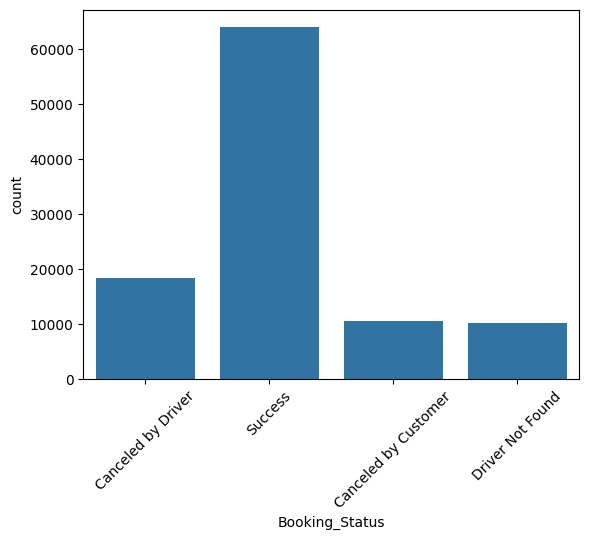

In [32]:
# Booking Status Distribution
sns.countplot(data=df, x='Booking_Status')
plt.xticks(rotation=45)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

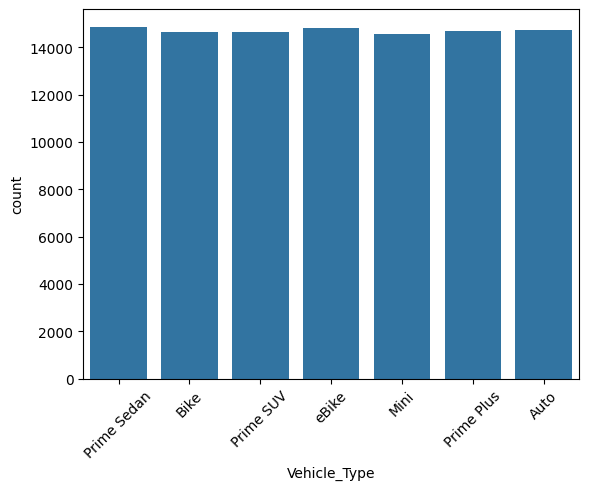

In [33]:
#Vehicle Type Usage
sns.countplot(data=df, x='Vehicle_Type')
plt.xticks(rotation=45)
plt.show

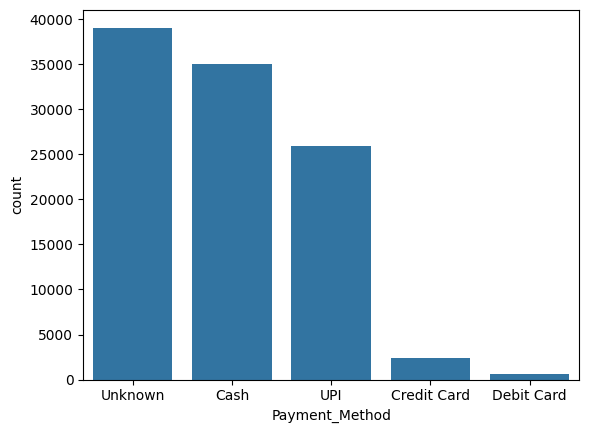

In [34]:
#Payment Method Distribution
sns.countplot(data=df, x='Payment_Method')
plt.show()

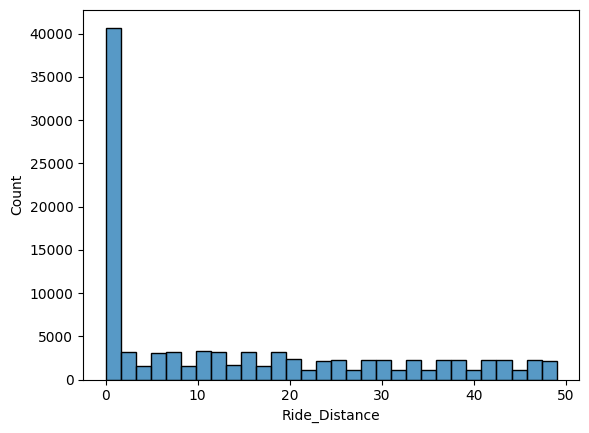

In [35]:
# Ride Distance Distribution 
sns.histplot(df['Ride_Distance'], bins=30)
plt.show()

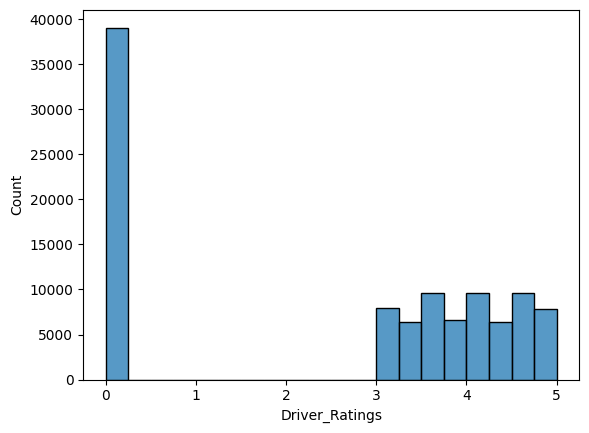

In [36]:
# Driver Ratings Distribution
sns.histplot(df['Driver_Ratings'], bins=20)
plt.show()

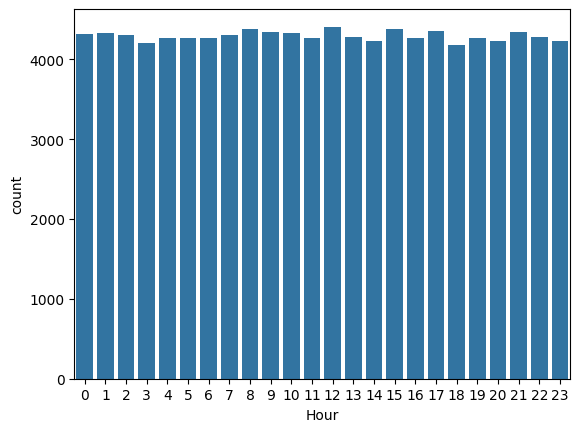

In [37]:
#Ride Demand by hour
sns.countplot(data=df, x='Hour')
plt.show()

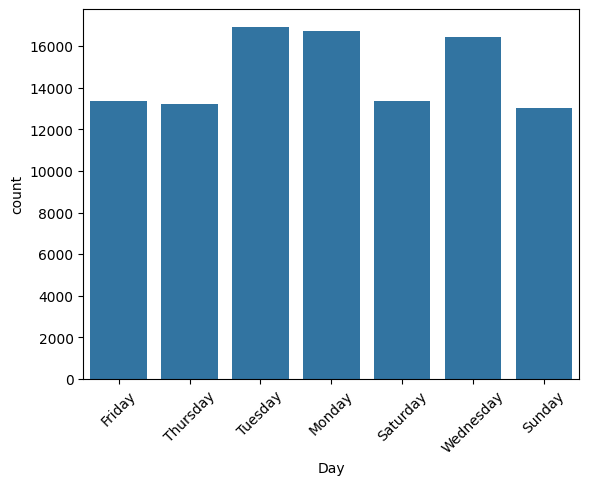

In [38]:
#Ride demand by Day
sns.countplot(data=df, x='Day')
plt.xticks(rotation=45)
plt.show()

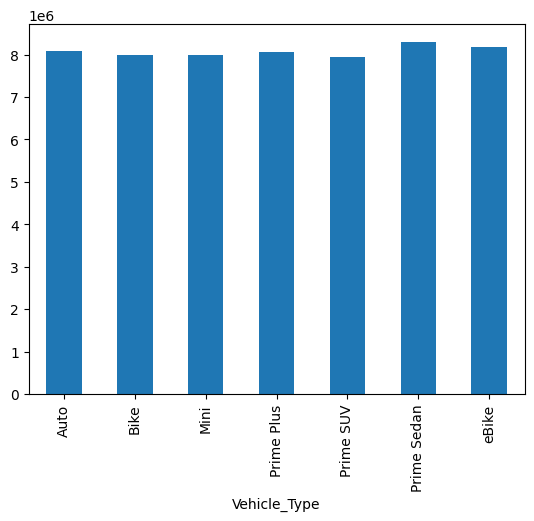

In [39]:
#Revenue by Vehicle Type
df.groupby('Vehicle_Type') ['Booking_Value'].sum().plot(kind='bar')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

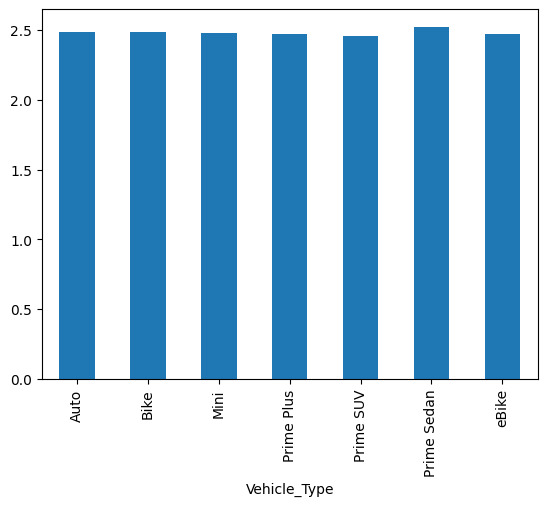

In [40]:
#Average customer rating by Vehicle type
df.groupby('Vehicle_Type')['Customer_Rating'].mean().plot(kind='bar')
plt.show

In [41]:
df.to_csv("clean_ola_rides.csv", index=False)